In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\pitch_data.csv")

In [3]:
# show the correlations for all numerical columns and is_strike column
#split the data into numerical and categorical columns
numerical = df.select_dtypes(include=[np.number])



In [4]:
# show the correlation between numerical columns and is_strike column
correlation = numerical.corr()
print(correlation['is_strike'])


is_strike             1.000000
is_swing              0.320548
inning                0.004669
is_bottom            -0.002048
balls                 0.025735
strikes              -0.066557
outs_before          -0.001264
is_lhp               -0.004102
is_lhb               -0.008640
bat_score_before     -0.005689
field_score           0.008646
basecode_before      -0.011187
plate_location_x      0.017444
plate_location_z      0.072338
rel_speed             0.029233
spin_rate             0.036681
induced_vert_break    0.041818
horizontal_break     -0.005618
Name: is_strike, dtype: float64


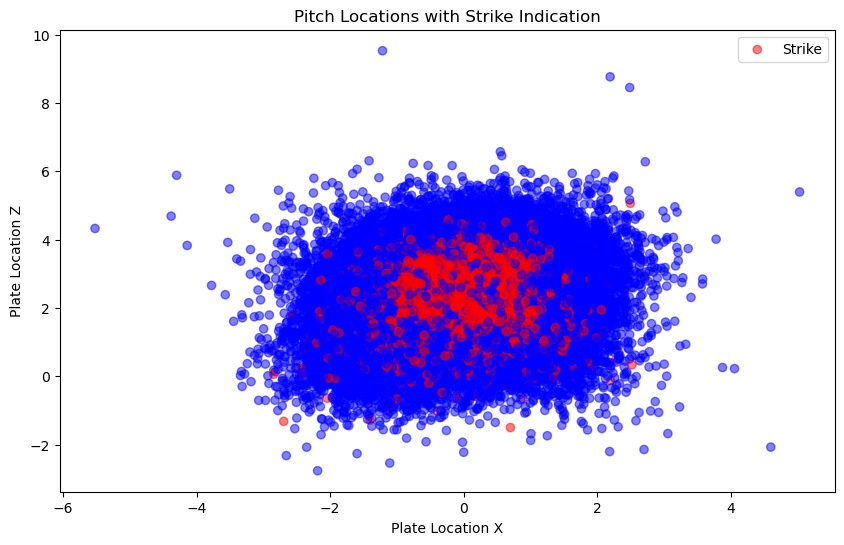

In [5]:
# Plotting the data points
plt.figure(figsize=(10, 6))
colors = np.where(df['is_strike'] == 1, 'r', 'b')
plt.scatter(df['plate_location_x'], df['plate_location_z'], c=colors, alpha=0.5, label='Strikes (red) and No Strikes (blue)')
plt.xlabel('Plate Location X')
plt.ylabel('Plate Location Z')
plt.title('Pitch Locations with Strike Indication')
plt.legend(['Strike', 'No Strike'])
plt.show()

pitcherid
0004a12374b272a1c591fd5122cde6a1    0.477966
00477095c539045c4fa26412a6515158    0.430962
00f87b889fa12e128d527db27208e6c3    0.509804
01d0ce950e4912ca1ad99eba10007876    0.382671
01f33ed6d78416b89310a90da135ddba    0.397959
                                      ...   
fe8abf400d5fe85fd19b1ca1a217360f    0.384615
fe9fcf0dd9db67a074e92520163de50c    0.452381
feeb2d2a496a1494c47d952468c03074    0.444444
ff452504b50b45d886657282206302e1    0.385281
ffb84c9f7af5813210e78f8183ad11b7    0.490486
Name: is_strike, Length: 543, dtype: float64


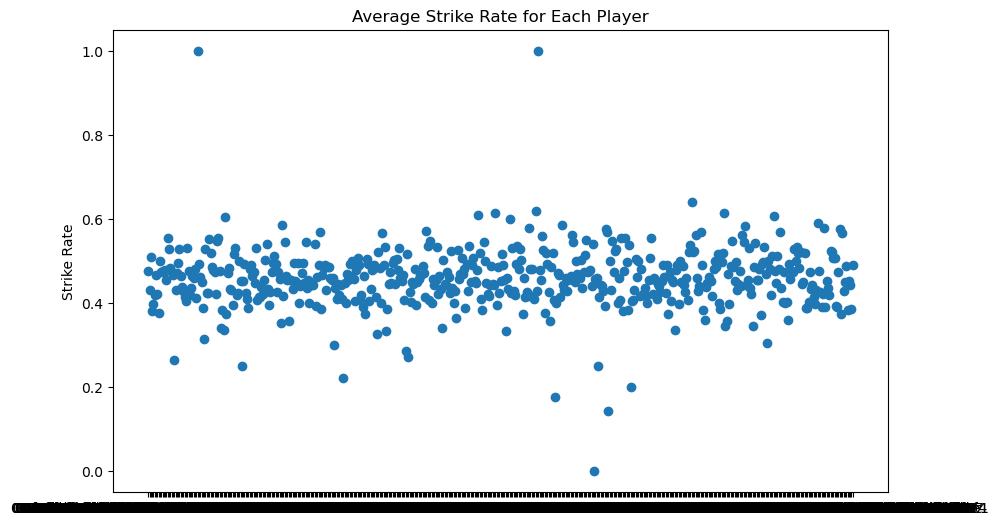

In [6]:
# show me the average strike rate for each player 
# group by player_id and calculate the average of is_strike column
strike_rate = df.groupby('pitcherid')['is_strike'].mean()
print(strike_rate)

# plot the average strike rate for each player using a dot plot
plt.figure(figsize=(10, 6))
plt.plot(strike_rate, 'o')
plt.xlabel('')
plt.ylabel('Strike Rate')
plt.title('Average Strike Rate for Each Player')
plt.show()


In [7]:
# show me the count of each player's pitches
# group by player_id and calculate the count of is_strike column
pitch_count = df.groupby('pitcherid')['is_strike'].count()
print(pitch_count)


pitcherid
0004a12374b272a1c591fd5122cde6a1    295
00477095c539045c4fa26412a6515158    239
00f87b889fa12e128d527db27208e6c3    204
01d0ce950e4912ca1ad99eba10007876    277
01f33ed6d78416b89310a90da135ddba     98
                                   ... 
fe8abf400d5fe85fd19b1ca1a217360f     26
fe9fcf0dd9db67a074e92520163de50c     42
feeb2d2a496a1494c47d952468c03074     72
ff452504b50b45d886657282206302e1    462
ffb84c9f7af5813210e78f8183ad11b7    473
Name: is_strike, Length: 543, dtype: int64


## Looking at 3 Clusters for All Pitches -Think About Keeping this ONE

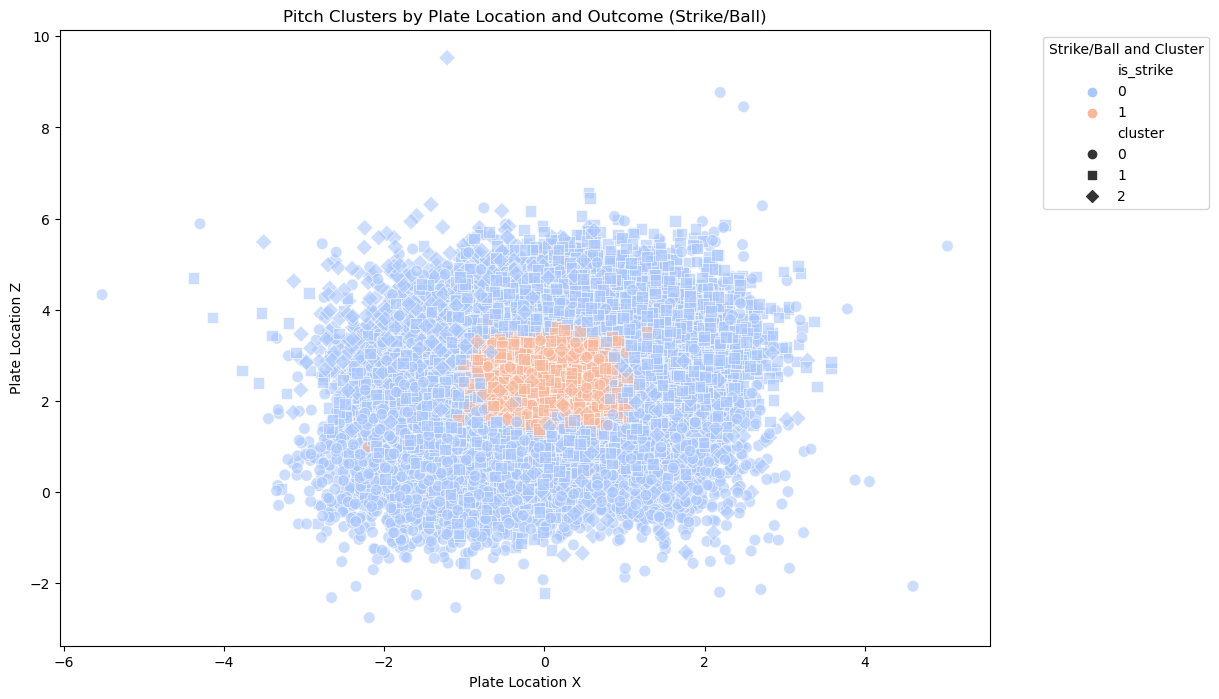

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data = pd.read_csv("C:\\Users\\Admin\\Downloads\\pitch_data.csv")

#drop the rows that have a 1 in the is_swing column
data = data[data['is_swing'] != 1]

# Filter only the relevant numeric features for clustering
numeric_features = data[['inning', 'is_bottom', 'balls', 'strikes', 'outs_before', 'is_lhp', 
                         'is_lhb', 'plate_location_x', 'plate_location_z', 'rel_speed', 
                         'spin_rate', 'induced_vert_break', 'horizontal_break']]

# Handle missing values using mean imputation
imputer = SimpleImputer(strategy='mean')
imputed_features = imputer.fit_transform(numeric_features)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(imputed_features)

# Perform K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled_features)

# Plot scatter plot for strike/ball distribution with enhanced interpretability
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='plate_location_x', 
    y='plate_location_z', 
    hue='is_strike', 
    style='cluster', 
    palette='coolwarm', 
    data=data, 
    markers=["o", "s", "D"],  # Different shapes for clusters
    alpha=0.6,  # Add transparency
    s=70  # Reduce marker size
)
plt.title("Pitch Clusters by Plate Location and Outcome (Strike/Ball)")
plt.xlabel("Plate Location X")
plt.ylabel("Plate Location Z")
plt.legend(title="Strike/Ball and Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()




## Looking at 6 Clusters for Just Pitches that are Called Strikes   

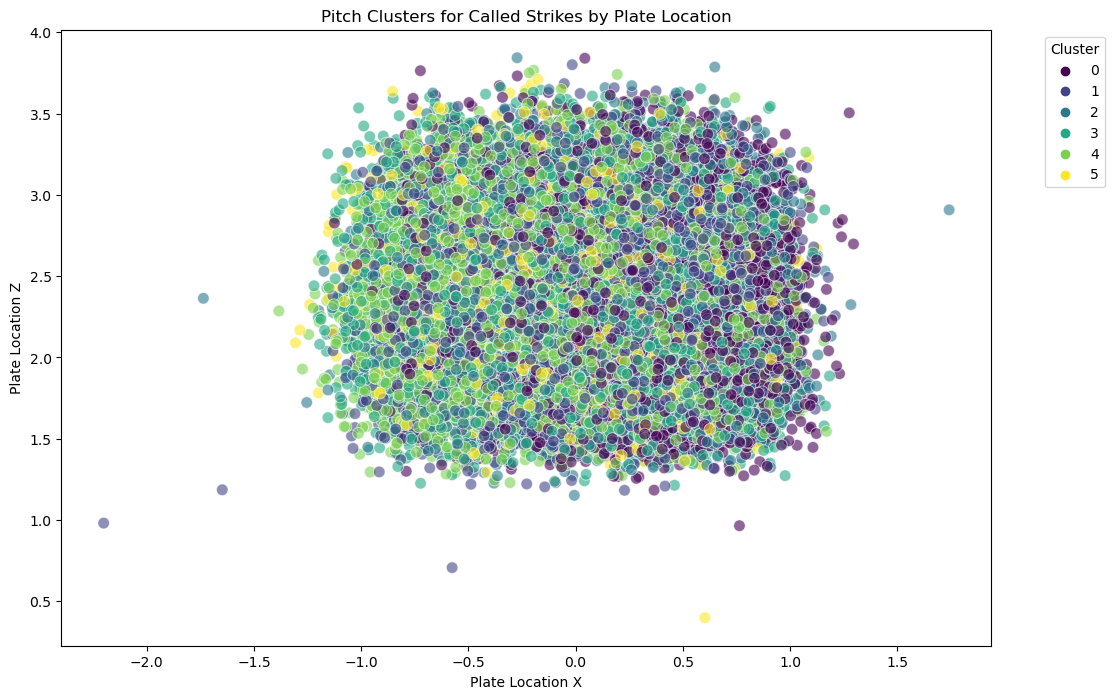

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data = pd.read_csv("C:\\Users\\Admin\\Downloads\\pitch_data.csv")

# Drop rows that have a 1 in the is_swing column
data = data[data['is_swing'] != 1]

# Filter only pitches that were called strikes
data = data[data['is_strike'] == 1]

# Filter only the relevant numeric features for clustering
numeric_features = data[['inning', 'is_bottom', 'balls', 'strikes', 'outs_before', 'is_lhp', 
                         'is_lhb', 'plate_location_x', 'plate_location_z', 'rel_speed', 
                         'spin_rate', 'induced_vert_break', 'horizontal_break']]

# Handle missing values using mean imputation
imputer = SimpleImputer(strategy='mean')
imputed_features = imputer.fit_transform(numeric_features)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(imputed_features)

# Perform K-Means clustering
kmeans = KMeans(n_clusters=6, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled_features)

# Plot scatter plot for strike distribution by clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='plate_location_x', 
    y='plate_location_z', 
    hue='cluster', 
    palette='viridis', 
    data=data, 
    markers=["o", "s", "D"],  # Different shapes for clusters
    alpha=0.6,  # Add transparency
    s=70  # Reduce marker size
)
plt.title("Pitch Clusters for Called Strikes by Plate Location")
plt.xlabel("Plate Location X")
plt.ylabel("Plate Location Z")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [10]:
## 

## FEATURE ENGINEERING 

## Creating a Smoothed Average Using Pitcher and Umpire Characteristics (CANT USE DATA LEAKAGE) - Include this or Some sort of Explanation of This 

- **Purpose**: To account for varying observation counts among pitchers and umpires.
- **Approach**:
  - For pitchers/umpires with few observations, the smoothed rate is closer to the overall strike rate, making the estimate more reliable.
  - For those with many observations, the smoothed rate approaches their individual rate, reflecting their specific tendencies more accurately.




In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
import numpy as np

# Load your dataset
data = pd.read_csv("C:\\Users\\Admin\\Downloads\\pitch_data.csv")

# Drop rows where batters swung (is_swing == 1)
data = data[data['is_swing'] != 1]

# Calculate the overall strike rate
overall_strike_rate = data['is_strike'].mean()

# Define the range of m values to try
m_values = [1, 5, 10, 20, 50, 100]
results = []

# Split the data into training and validation sets
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Find the optimal m value using cross-validation
for m in m_values:
    # Calculate smoothed strike rates for pitchers in the training data
    pitcher_stats = train_data.groupby('pitcherid')['is_strike'].agg(['mean', 'count'])
    pitcher_stats['smoothed_pitcher_strike_rate'] = (
        (overall_strike_rate * m + pitcher_stats['mean'] * pitcher_stats['count']) /
        (m + pitcher_stats['count'])
    )
    
    # Calculate smoothed strike rates for umpires in the training data
    umpire_stats = train_data.groupby('hp_umpid')['is_strike'].agg(['mean', 'count'])
    umpire_stats['smoothed_umpire_strike_rate'] = (
        (overall_strike_rate * m + umpire_stats['mean'] * umpire_stats['count']) /
        (m + umpire_stats['count'])
    )
    
    # Map the smoothed rates back to the validation data
    val_data['pitcher_strike_rate'] = val_data['pitcherid'].map(pitcher_stats['smoothed_pitcher_strike_rate'])
    val_data['umpire_strike_rate'] = val_data['hp_umpid'].map(umpire_stats['smoothed_umpire_strike_rate'])
    
    # Fill NaN values with the overall strike rate
    val_data['pitcher_strike_rate'].fillna(overall_strike_rate, inplace=True)
    val_data['umpire_strike_rate'].fillna(overall_strike_rate, inplace=True)
    
    # Train a logistic regression model
    model = LogisticRegression()
    model.fit(val_data[['pitcher_strike_rate', 'umpire_strike_rate']], val_data['is_strike'])
    
    # Evaluate the model on the validation set using log loss
    predictions = model.predict_proba(val_data[['pitcher_strike_rate', 'umpire_strike_rate']])[:, 1]
    score = log_loss(val_data['is_strike'], predictions)
    results.append((m, score))

# Determine the optimal m value
best_m, best_score = min(results, key=lambda x: x[1])
print(f"Optimal m: {best_m}, Log Loss: {best_score}")

# Now apply target encoding with the optimal m value on the entire dataset
pitcher_stats = data.groupby('pitcherid')['is_strike'].agg(['mean', 'count'])
pitcher_stats['smoothed_pitcher_strike_rate'] = (
    (overall_strike_rate * best_m + pitcher_stats['mean'] * pitcher_stats['count']) /
    (best_m + pitcher_stats['count'])
)
data['pitcher_strike_rate'] = data['pitcherid'].map(pitcher_stats['smoothed_pitcher_strike_rate'])

umpire_stats = data.groupby('hp_umpid')['is_strike'].agg(['mean', 'count'])
umpire_stats['smoothed_umpire_strike_rate'] = (
    (overall_strike_rate * best_m + umpire_stats['mean'] * umpire_stats['count']) /
    (best_m + umpire_stats['count'])
)
data['umpire_strike_rate'] = data['hp_umpid'].map(umpire_stats['smoothed_umpire_strike_rate'])

# Fill NaN values with the overall strike rate for any unseen pitcher or umpire
data['pitcher_strike_rate'].fillna(overall_strike_rate, inplace=True)
data['umpire_strike_rate'].fillna(overall_strike_rate, inplace=True)

# Inspect the final dataset with target encoding applied
print(data[['pitcherid', 'pitcher_strike_rate', 'hp_umpid', 'umpire_strike_rate']].head())


Optimal m: 50, Log Loss: 0.6213378408717914
                          pitcherid  pitcher_strike_rate  \
0  4565dcf730add884e7d810154ede64c6             0.324297   
1  4565dcf730add884e7d810154ede64c6             0.324297   
3  4565dcf730add884e7d810154ede64c6             0.324297   
4  4565dcf730add884e7d810154ede64c6             0.324297   
5  4565dcf730add884e7d810154ede64c6             0.324297   

                           hp_umpid  umpire_strike_rate  
0  8400a000df323939dc6e63844149df8f            0.310302  
1  8400a000df323939dc6e63844149df8f            0.310302  
3  8400a000df323939dc6e63844149df8f            0.310302  
4  8400a000df323939dc6e63844149df8f            0.310302  
5  8400a000df323939dc6e63844149df8f            0.310302  


## Incremental Target Encoding with Smoothing Code - INCLUDE THIS 

- **Purpose**: To account for varying observation counts among pitchers and umpires.
- **Approach**:
  - For pitchers/umpires with few observations, the smoothed rate is closer to the overall strike rate, making the estimate more reliable.
  - For those with many observations, the smoothed rate approaches their individual rate, reflecting their specific tendencies more accurately.




## Testing the optimal M value in the Smoothing Code T - THIS IS JUST TO FIND THAT THE OPTIMAL VALUE FOR M IN THE SMOOTH CALCULATION IS 100 

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import TimeSeriesSplit

# Load the dataset
data = pd.read_csv("C:\\Users\\Admin\\Downloads\\pitch_data.csv")

# Filter out rows where the batter swung
data = data[data['is_swing'] != 1]

# Overall strike rate across all pitches for initialization
overall_strike_rate = data['is_strike'].mean()

# Define range of m values to test
m_values = [1, 5, 10, 20, 50, 100]
results = []

# Time series split to avoid future data leakage
tscv = TimeSeriesSplit(n_splits=5)  # You can adjust the number of splits

# Iterate over different m values to find the optimal one
for m in m_values:
    log_loss_scores = []
    
    for train_index, test_index in tscv.split(data):
        train_data, test_data = data.iloc[train_index], data.iloc[test_index]
        
        # Initialize dictionaries to store counts and strike counts for each pitcher and umpire
        pitcher_counts = {}
        pitcher_strike_counts = {}
        umpire_counts = {}
        umpire_strike_counts = {}

        smoothed_pitcher_rates = []
        smoothed_umpire_rates = []
        
        # Calculate smoothed strike rates incrementally for the training set
        for _, row in train_data.iterrows():
            pitcher = row['pitcherid']
            umpire = row['hp_umpid']
            
            # Calculate smoothed strike rate for the pitcher
            pitcher_strike_rate = pitcher_strike_counts.get(pitcher, 0) / max(pitcher_counts.get(pitcher, 1), 1)
            smoothed_pitcher_rate = (overall_strike_rate * m + pitcher_strike_rate * pitcher_counts.get(pitcher, 0)) / (m + pitcher_counts.get(pitcher, 0))
            
            # Calculate smoothed strike rate for the umpire
            umpire_strike_rate = umpire_strike_counts.get(umpire, 0) / max(umpire_counts.get(umpire, 1), 1)
            smoothed_umpire_rate = (overall_strike_rate * m + umpire_strike_rate * umpire_counts.get(umpire, 0)) / (m + umpire_counts.get(umpire, 0))
            
            # Append the smoothed rates to lists
            smoothed_pitcher_rates.append(smoothed_pitcher_rate)
            smoothed_umpire_rates.append(smoothed_umpire_rate)
            
            # Update counts
            pitcher_counts[pitcher] = pitcher_counts.get(pitcher, 0) + 1
            pitcher_strike_counts[pitcher] = pitcher_strike_counts.get(pitcher, 0) + row['is_strike']
            umpire_counts[umpire] = umpire_counts.get(umpire, 0) + 1
            umpire_strike_counts[umpire] = umpire_strike_counts.get(umpire, 0) + row['is_strike']
        
        # Add smoothed rates to the training data
        train_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
        train_data['smoothed_umpire_rate'] = smoothed_umpire_rates
        
        # Fit a simple model on the training data
        model = LogisticRegression()
        model.fit(train_data[['smoothed_pitcher_rate', 'smoothed_umpire_rate']], train_data['is_strike'])
        
        # Calculate smoothed rates for the test data using prior training data
        smoothed_pitcher_rates_test = []
        smoothed_umpire_rates_test = []

        for _, row in test_data.iterrows():
            pitcher = row['pitcherid']
            umpire = row['hp_umpid']
            
            pitcher_strike_rate = pitcher_strike_counts.get(pitcher, 0) / max(pitcher_counts.get(pitcher, 1), 1)
            smoothed_pitcher_rate = (overall_strike_rate * m + pitcher_strike_rate * pitcher_counts.get(pitcher, 0)) / (m + pitcher_counts.get(pitcher, 0))
            
            umpire_strike_rate = umpire_strike_counts.get(umpire, 0) / max(umpire_counts.get(umpire, 1), 1)
            smoothed_umpire_rate = (overall_strike_rate * m + umpire_strike_rate * umpire_counts.get(umpire, 0)) / (m + umpire_counts.get(umpire, 0))
            
            smoothed_pitcher_rates_test.append(smoothed_pitcher_rate)
            smoothed_umpire_rates_test.append(smoothed_umpire_rate)
        
        # Add the smoothed rates to the test data
        test_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates_test
        test_data['smoothed_umpire_rate'] = smoothed_umpire_rates_test
        
        # Make predictions and calculate log loss
        predictions = model.predict_proba(test_data[['smoothed_pitcher_rate', 'smoothed_umpire_rate']])[:, 1]
        score = log_loss(test_data['is_strike'], predictions)
        log_loss_scores.append(score)
    
    # Average log loss across folds for current m
    average_log_loss = np.mean(log_loss_scores)
    results.append((m, average_log_loss))
    print(f"m={m}, Average Log Loss={average_log_loss}")

# Find the m with the lowest average log loss
optimal_m, best_score = min(results, key=lambda x: x[1])
print(f"\nOptimal m: {optimal_m}, with Log Loss: {best_score}")


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_umpire_rate'] = smoothed_umpire_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

m=1, Average Log Loss=0.6223288255573091


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_umpire_rate'] = smoothed_umpire_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

m=5, Average Log Loss=0.6222225335259868


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_umpire_rate'] = smoothed_umpire_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

...

C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_umpire_rate'] = smoothed_umpire_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

m=50, Average Log Loss=0.6218964784081085


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_umpire_rate'] = smoothed_umpire_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

m=100, Average Log Loss=0.6218827247077787

Optimal m: 100, with Log Loss: 0.6218827247077787


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pitcher_rate'] = smoothed_pitcher_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\1566465716.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_umpire_rate'] = smoothed_umpire_rates_test


# Generating the New Feature ( The thing with this is that it is just an overall trend ) Creating Smoothed Pitcher and Umpire Strike Rates Based on the Optimal M value that was found -KEEP THIS LOOK INTO DOING THE SAME FOR HITTER AND CATCHERS 

In [13]:
import pandas as pd

# Load the dataset
data = pd.read_csv("C:\\Users\\Admin\\Downloads\\pitch_data.csv")

# Filter out rows where the batter swung
data = data[data['is_swing'] != 1]

# Overall strike rate across all pitches for initialization
overall_strike_rate = data['is_strike'].mean()

# Optimal smoothing parameter found
m = 100

# Initialize dictionaries to store counts and strike counts for each pitcher and umpire
pitcher_counts = {}
pitcher_strike_counts = {}
umpire_counts = {}
umpire_strike_counts = {}

# Lists to store the smoothed strike rates for each pitch
smoothed_pitcher_rates = []
smoothed_umpire_rates = []

# Calculate smoothed strike rates incrementally for the entire dataset using m = 100
for index, row in data.iterrows():
    pitcher = row['pitcherid']
    umpire = row['hp_umpid']
    
    # Calculate smoothed strike rate for the pitcher
    pitcher_strike_rate = pitcher_strike_counts.get(pitcher, 0) / max(pitcher_counts.get(pitcher, 1), 1)
    smoothed_pitcher_rate = (overall_strike_rate * m + pitcher_strike_rate * pitcher_counts.get(pitcher, 0)) / (m + pitcher_counts.get(pitcher, 0))
    
    # Calculate smoothed strike rate for the umpire
    umpire_strike_rate = umpire_strike_counts.get(umpire, 0) / max(umpire_counts.get(umpire, 1), 1)
    smoothed_umpire_rate = (overall_strike_rate * m + umpire_strike_rate * umpire_counts.get(umpire, 0)) / (m + umpire_counts.get(umpire, 0))
    
    # Append the calculated smoothed rates to the lists
    smoothed_pitcher_rates.append(smoothed_pitcher_rate)
    smoothed_umpire_rates.append(smoothed_umpire_rate)
    
    # Update the counts and strike counts for the pitcher
    pitcher_counts[pitcher] = pitcher_counts.get(pitcher, 0) + 1
    pitcher_strike_counts[pitcher] = pitcher_strike_counts.get(pitcher, 0) + row['is_strike']
    
    # Update the counts and strike counts for the umpire
    umpire_counts[umpire] = umpire_counts.get(umpire, 0) + 1
    umpire_strike_counts[umpire] = umpire_strike_counts.get(umpire, 0) + row['is_strike']

# Add the smoothed rates to the DataFrame as new columns
data['smoothed_pitcher_rate'] = smoothed_pitcher_rates
data['smoothed_umpire_rate'] = smoothed_umpire_rates

# Display the first few rows of the dataset to check the new features
print(data[['pitcherid', 'smoothed_pitcher_rate', 'hp_umpid', 'smoothed_umpire_rate']].head())


                          pitcherid  smoothed_pitcher_rate  \
0  4565dcf730add884e7d810154ede64c6               0.313371   
1  4565dcf730add884e7d810154ede64c6               0.320169   
3  4565dcf730add884e7d810154ede64c6               0.317030   
4  4565dcf730add884e7d810154ede64c6               0.313953   
5  4565dcf730add884e7d810154ede64c6               0.310934   

                           hp_umpid  smoothed_umpire_rate  
0  8400a000df323939dc6e63844149df8f              0.313371  
1  8400a000df323939dc6e63844149df8f              0.320169  
3  8400a000df323939dc6e63844149df8f              0.317030  
4  8400a000df323939dc6e63844149df8f              0.313953  
5  8400a000df323939dc6e63844149df8f              0.310934  


## Creating a Feature that Looks a Smoothed Rate but for the Relationship Between Pitcher and Umpire -KEEP THIS 

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import TimeSeriesSplit


# Overall strike rate across all pitches for initialization
overall_strike_rate = data['is_strike'].mean()

# Define the range of m values to test
m_values = [1, 5, 10, 20, 50, 100, 200]
results = []

# Time series split to avoid data leakage by only using past data for predictions
tscv = TimeSeriesSplit(n_splits=5)  # Adjust the number of splits if needed

# Iterate over different m values to find the optimal one
for m in m_values:
    log_loss_scores = []
    
    # Split data into training and test sets sequentially
    for train_index, test_index in tscv.split(data):
        train_data, test_data = data.iloc[train_index], data.iloc[test_index]
        
        # Initialize dictionaries for the pair (pitcher-umpire) counts and strike counts
        pair_counts = {}
        pair_strike_counts = {}
        
        smoothed_pair_rates = []
        
        # Calculate smoothed rates incrementally for the training set
        for _, row in train_data.iterrows():
            pair = (row['pitcherid'], row['hp_umpid'])
            
            # Calculate smoothed strike rate for the pair
            pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
            smoothed_pair_rate = (overall_strike_rate * m + pair_strike_rate * pair_counts.get(pair, 0)) / (m + pair_counts.get(pair, 0))
            
            # Append the calculated smoothed rate to the list
            smoothed_pair_rates.append(smoothed_pair_rate)
            
            # Update counts for the pair
            pair_counts[pair] = pair_counts.get(pair, 0) + 1
            pair_strike_counts[pair] = pair_strike_counts.get(pair, 0) + row['is_strike']
        
        # Add smoothed rates to the training data
        train_data['smoothed_pair_rateup'] = smoothed_pair_rates
        
        # Train a simple model on the training data
        model = LogisticRegression()
        model.fit(train_data[['smoothed_pair_rateup']], train_data['is_strike'])
        
        # Calculate smoothed rates for the test data using prior training data
        smoothed_pair_rates_test = []

        for _, row in test_data.iterrows():
            pair = (row['pitcherid'], row['hp_umpid'])
            
            pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
            smoothed_pair_rate = (overall_strike_rate * m + pair_strike_rate * pair_counts.get(pair, 0)) / (m + pair_counts.get(pair, 0))
            
            smoothed_pair_rates_test.append(smoothed_pair_rate)
        
        # Add smoothed rates to the test data
        test_data['smoothed_pair_rateup'] = smoothed_pair_rates_test
        
        # Make predictions and calculate log loss
        predictions = model.predict_proba(test_data[['smoothed_pair_rateup']])[:, 1]
        score = log_loss(test_data['is_strike'], predictions)
        log_loss_scores.append(score)
    
    # Average log loss for current m
    average_log_loss = np.mean(log_loss_scores)
    results.append((m, average_log_loss))
    print(f"m={m}, Average Log Loss={average_log_loss}")

# Find the optimal m value with the lowest average log loss
optimal_m, best_score = min(results, key=lambda x: x[1])
print(f"\nOptimal m: {optimal_m}, Log Loss: {best_score}")

# Now, using the optimal m value, calculate the smoothed pair strike rate for the entire dataset
pair_counts = {}
pair_strike_counts = {}

# List to store the smoothed strike rate for each pitcher-umpire pair
smoothed_pair_rates = []

for _, row in data.iterrows():
    pair = (row['pitcherid'], row['hp_umpid'])
    
    # Calculate smoothed strike rate for the pair with the optimal m
    pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
    smoothed_pair_rate = (overall_strike_rate * optimal_m + pair_strike_rate * pair_counts.get(pair, 0)) / (optimal_m + pair_counts.get(pair, 0))
    
    smoothed_pair_rates.append(smoothed_pair_rate)
    
    # Update counts for the pair
    pair_counts[pair] = pair_counts.get(pair, 0) + 1
    pair_strike_counts[pair] = pair_strike_counts.get(pair, 0) + row['is_strike']

# Add the smoothed pair strike rate to the dataset
data['smoothed_pair_rateup'] = smoothed_pair_rates

# Display the first few rows of the dataset to verify the new feature
print(data[['pitcherid', 'hp_umpid', 'smoothed_pair_rateup']].head())


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateup'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateup'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=1, Average Log Loss=0.6219691025811059


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateup'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateup'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=5, Average Log Loss=0.62197605194804


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateup'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateup'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

...

m=50, Average Log Loss=0.6219773675251624


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateup'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateup'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=100, Average Log Loss=0.6219778168605571


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateup'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateup'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3297815664.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=200, Average Log Loss=0.6219654995879754

Optimal m: 200, Log Loss: 0.6219654995879754
                          pitcherid                          hp_umpid  \
0  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
1  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
3  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
4  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
5  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   

   smoothed_pair_rateup  
0              0.313371  
1              0.316787  
3              0.315219  
4              0.313666  
5              0.312129  


## Filling Missing Data Points in Spinrate - KEEP THIS 

In [15]:
# Fill in the missing values in spinrate column with the mean value for the same pitch type
data['spin_rate'] = data.groupby('pitch_type')['spin_rate'].transform(lambda x: x.fillna(x.mean()))

## Creating A Dummified Pitch Type Column - KEEP THIS 

In [16]:
# dummify the pitch type column
data = pd.get_dummies(data, columns=['pitch_type'])



## Creating A Dummified Column for Inning - KEEP THIS 

In [17]:
#dummify the inning column
data = pd.get_dummies(data, columns=['inning'])

## Dealing with Missing Values 

In [18]:
data 

,is_strike,is_swing,is_bottom,balls,strikes,outs_before,is_lhp,is_lhb,bat_score_before,field_score,...,inning_9,inning_10,inning_11,inning_12,inning_13,inning_14,inning_15,inning_16,inning_17,inning_18
0,1,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,0,0,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,1,0,0,2,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106069,0,0,0,0,0,0,0,1,1,2,...,True,False,False,False,False,False,False,False,False,False
106071,1,0,0,1,1,0,0,1,1,2,...,True,False,False,False,False,False,False,False,False,False
106073,0,0,0,0,0,1,0,0,1,2,...,True,False,False,False,False,False,False,False,False,False
106074,1,0,0,1,0,1,0,0,1,2,...,True,False,False,False,False,False,False,False,False,False


## Umpire Catcher Relationship Smooth - KEEP THIS 

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import TimeSeriesSplit


# Overall strike rate across all pitches for initialization
overall_strike_rate = data['is_strike'].mean()

# Define the range of m values to test
m_values = [1, 5, 10, 20, 50, 100, 200]
results = []

# Time series split to avoid data leakage by only using past data for predictions
tscv = TimeSeriesSplit(n_splits=5)  # Adjust the number of splits if needed

# Iterate over different m values to find the optimal one
for m in m_values:
    log_loss_scores = []
    
    # Split data into training and test sets sequentially
    for train_index, test_index in tscv.split(data):
        train_data, test_data = data.iloc[train_index], data.iloc[test_index]
        
        # Initialize dictionaries for the pair (pitcher-umpire) counts and strike counts
        pair_counts = {}
        pair_strike_counts = {}
        
        smoothed_pair_rates = []
        
        # Calculate smoothed rates incrementally for the training set
        for _, row in train_data.iterrows():
            pair = (row['cid'], row['hp_umpid'])
            
            # Calculate smoothed strike rate for the pair
            pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
            smoothed_pair_rate = (overall_strike_rate * m + pair_strike_rate * pair_counts.get(pair, 0)) / (m + pair_counts.get(pair, 0))
            
            # Append the calculated smoothed rate to the list
            smoothed_pair_rates.append(smoothed_pair_rate)
            
            # Update counts for the pair
            pair_counts[pair] = pair_counts.get(pair, 0) + 1
            pair_strike_counts[pair] = pair_strike_counts.get(pair, 0) + row['is_strike']
        
        # Add smoothed rates to the training data
        train_data['smoothed_pair_ratecu'] = smoothed_pair_rates
        
        # Train a simple model on the training data
        model = LogisticRegression()
        model.fit(train_data[['smoothed_pair_ratecu']], train_data['is_strike'])
        
        # Calculate smoothed rates for the test data using prior training data
        smoothed_pair_rates_test = []

        for _, row in test_data.iterrows():
            pair = (row['cid'], row['hp_umpid'])
            
            pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
            smoothed_pair_rate = (overall_strike_rate * m + pair_strike_rate * pair_counts.get(pair, 0)) / (m + pair_counts.get(pair, 0))
            
            smoothed_pair_rates_test.append(smoothed_pair_rate)
        
        # Add smoothed rates to the test data
        test_data['smoothed_pair_ratecu'] = smoothed_pair_rates_test
        
        # Make predictions and calculate log loss
        predictions = model.predict_proba(test_data[['smoothed_pair_ratecu']])[:, 1]
        score = log_loss(test_data['is_strike'], predictions)
        log_loss_scores.append(score)
    
    # Average log loss for current m
    average_log_loss = np.mean(log_loss_scores)
    results.append((m, average_log_loss))
    print(f"m={m}, Average Log Loss={average_log_loss}")

# Find the optimal m value with the lowest average log loss
optimal_m, best_score = min(results, key=lambda x: x[1])
print(f"\nOptimal m: {optimal_m}, Log Loss: {best_score}")

# Now, using the optimal m value, calculate the smoothed pair strike rate for the entire dataset
pair_counts = {}
pair_strike_counts = {}

# List to store the smoothed strike rate for each pitcher-umpire pair
smoothed_pair_rates = []

for _, row in data.iterrows():
    pair = (row['cid'], row['hp_umpid'])
    
    # Calculate smoothed strike rate for the pair with the optimal m
    pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
    smoothed_pair_rate = (overall_strike_rate * optimal_m + pair_strike_rate * pair_counts.get(pair, 0)) / (optimal_m + pair_counts.get(pair, 0))
    
    smoothed_pair_rates.append(smoothed_pair_rate)
    
    # Update counts for the pair
    pair_counts[pair] = pair_counts.get(pair, 0) + 1
    pair_strike_counts[pair] = pair_strike_counts.get(pair, 0) + row['is_strike']

# Add the smoothed pair strike rate to the dataset
data['smoothed_pair_ratecu'] = smoothed_pair_rates

# Display the first few rows of the dataset to verify the new feature
print(data[['pitcherid', 'hp_umpid', 'smoothed_pair_ratecu']].head())


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_ratecu'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_ratecu'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=1, Average Log Loss=0.621993788450099


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_ratecu'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_ratecu'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=5, Average Log Loss=0.621992525429199


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_ratecu'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_ratecu'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

...

m=50, Average Log Loss=0.6219815504760755


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_ratecu'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_ratecu'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=100, Average Log Loss=0.6219661922920773


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_ratecu'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_ratecu'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2618233989.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=200, Average Log Loss=0.6219658126165739

Optimal m: 200, Log Loss: 0.6219658126165739
                          pitcherid                          hp_umpid  \
0  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
1  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
3  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
4  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   
5  4565dcf730add884e7d810154ede64c6  8400a000df323939dc6e63844149df8f   

   smoothed_pair_ratecu  
0              0.313371  
1              0.316787  
3              0.315219  
4              0.313666  
5              0.312129  


## Smoothed Umpire Batter Relationship -KEEP THIS 


In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import TimeSeriesSplit


# Overall strike rate across all pitches for initialization
overall_strike_rate = data['is_strike'].mean()

# Define the range of m values to test
m_values = [1, 5, 10, 20, 50, 100, 200]
results = []

# Time series split to avoid data leakage by only using past data for predictions
tscv = TimeSeriesSplit(n_splits=5)  # Adjust the number of splits if needed

# Iterate over different m values to find the optimal one
for m in m_values:
    log_loss_scores = []
    
    # Split data into training and test sets sequentially
    for train_index, test_index in tscv.split(data):
        train_data, test_data = data.iloc[train_index], data.iloc[test_index]
        
        # Initialize dictionaries for the pair (pitcher-umpire) counts and strike counts
        pair_counts = {}
        pair_strike_counts = {}
        
        smoothed_pair_rates = []
        
        # Calculate smoothed rates incrementally for the training set
        for _, row in train_data.iterrows():
            pair = (row['batterid'], row['hp_umpid'])
            
            # Calculate smoothed strike rate for the pair
            pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
            smoothed_pair_rate = (overall_strike_rate * m + pair_strike_rate * pair_counts.get(pair, 0)) / (m + pair_counts.get(pair, 0))
            
            # Append the calculated smoothed rate to the list
            smoothed_pair_rates.append(smoothed_pair_rate)
            
            # Update counts for the pair
            pair_counts[pair] = pair_counts.get(pair, 0) + 1
            pair_strike_counts[pair] = pair_strike_counts.get(pair, 0) + row['is_strike']
        
        # Add smoothed rates to the training data
        train_data['smoothed_pair_rateub'] = smoothed_pair_rates
        
        # Train a simple model on the training data
        model = LogisticRegression()
        model.fit(train_data[['smoothed_pair_rateub']], train_data['is_strike'])
        
        # Calculate smoothed rates for the test data using prior training data
        smoothed_pair_rates_test = []

        for _, row in test_data.iterrows():
            pair = (row['batterid'], row['hp_umpid'])
            
            pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
            smoothed_pair_rate = (overall_strike_rate * m + pair_strike_rate * pair_counts.get(pair, 0)) / (m + pair_counts.get(pair, 0))
            
            smoothed_pair_rates_test.append(smoothed_pair_rate)
        
        # Add smoothed rates to the test data
        test_data['smoothed_pair_rateub'] = smoothed_pair_rates_test
        
        # Make predictions and calculate log loss
        predictions = model.predict_proba(test_data[['smoothed_pair_rateub']])[:, 1]
        score = log_loss(test_data['is_strike'], predictions)
        log_loss_scores.append(score)
    
    # Average log loss for current m
    average_log_loss = np.mean(log_loss_scores)
    results.append((m, average_log_loss))
    print(f"m={m}, Average Log Loss={average_log_loss}")

# Find the optimal m value with the lowest average log loss
optimal_m, best_score = min(results, key=lambda x: x[1])
print(f"\nOptimal m: {optimal_m}, Log Loss: {best_score}")

# Now, using the optimal m value, calculate the smoothed pair strike rate for the entire dataset
pair_counts = {}
pair_strike_counts = {}

# List to store the smoothed strike rate for each pitcher-umpire pair
smoothed_pair_rates = []

for _, row in data.iterrows():
    pair = (row['batterid'], row['hp_umpid'])
    
    # Calculate smoothed strike rate for the pair with the optimal m
    pair_strike_rate = pair_strike_counts.get(pair, 0) / max(pair_counts.get(pair, 1), 1)
    smoothed_pair_rate = (overall_strike_rate * optimal_m + pair_strike_rate * pair_counts.get(pair, 0)) / (optimal_m + pair_counts.get(pair, 0))
    
    smoothed_pair_rates.append(smoothed_pair_rate)
    
    # Update counts for the pair
    pair_counts[pair] = pair_counts.get(pair, 0) + 1
    pair_strike_counts[pair] = pair_strike_counts.get(pair, 0) + row['is_strike']

# Add the smoothed pair strike rate to the dataset
data['smoothed_pair_rateub'] = smoothed_pair_rates

# Display the first few rows of the dataset to verify the new featur

C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateub'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateub'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=1, Average Log Loss=0.6220927020651069


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateub'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateub'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=5, Average Log Loss=0.622116064880482


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateub'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateub'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

...

m=50, Average Log Loss=0.622037675094326


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateub'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateub'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=100, Average Log Loss=0.6219927884974842


C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['smoothed_pair_rateub'] = smoothed_pair_rates
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['smoothed_pair_rateub'] = smoothed_pair_rates_test
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\2147716315.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

m=200, Average Log Loss=0.6219658068111491

Optimal m: 200, Log Loss: 0.6219658068111491


## Euclidean Distance Feaure 

In [21]:
# Filter for non-swung pitches that were called strikes to calculate the strike zone bounds
called_strikes = data[(data['is_swing'] == 0) & (data['is_strike'] == 1)]

# Calculate the center of the strike zone
x_bounds = np.percentile(called_strikes['plate_location_x'], [2.5, 97.5])
z_bounds = np.percentile(called_strikes['plate_location_z'], [2.5, 97.5])

x_center = (x_bounds[0] + x_bounds[1]) / 2
z_center = (z_bounds[0] + z_bounds[1]) / 2

print("Center of Strike Zone (X, Z):", (x_center, z_center))

# Calculate the Euclidean distance from the center of the strike zone for each pitch
data['distance_from_center'] = np.sqrt((data['plate_location_x'] - x_center)**2 + 
                                       (data['plate_location_z'] - z_center)**2)

Center of Strike Zone (X, Z): (-0.005199999999999982, 2.424)


In [22]:
data

,is_strike,is_swing,is_bottom,balls,strikes,outs_before,is_lhp,is_lhb,bat_score_before,field_score,...,inning_12,inning_13,inning_14,inning_15,inning_16,inning_17,inning_18,smoothed_pair_ratecu,smoothed_pair_rateub,distance_from_center
0,1,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,0.313371,0.313371,0.845713
1,0,0,0,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,0.316787,0.316787,0.858221
3,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,0.315219,0.313371,2.123938
4,0,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,0.313666,0.311812,1.661370
5,1,0,0,2,0,0,0,0,0,0,...,False,False,False,False,False,False,False,0.312129,0.310268,0.970322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106069,0,0,0,0,0,0,0,1,1,2,...,False,False,False,False,False,False,False,0.302474,0.301258,1.655736
106071,1,0,0,1,1,0,0,1,1,2,...,False,False,False,False,False,False,False,0.301510,0.299882,0.989716
106073,0,0,0,0,0,1,0,0,1,2,...,False,False,False,False,False,False,False,0.303728,0.311812,2.361747
106074,1,0,0,1,0,1,0,0,1,2,...,False,False,False,False,False,False,False,0.302767,0.310268,0.626037


In [23]:
# Dummify the umpireid column
data = pd.get_dummies(data, columns=['hp_umpid'])


In [24]:
data

,is_strike,is_swing,is_bottom,balls,strikes,outs_before,is_lhp,is_lhb,bat_score_before,field_score,...,hp_umpid_de481aef01830149d99db50a4daad206,hp_umpid_e5badba539f37a6f2c6ddca10fdd65fe,hp_umpid_e837c5c3c9a6374da7f6df416dd4b968,hp_umpid_ef4596e4c335e85e87e21f835ac813b4,hp_umpid_eff514a481bbbc0a0c04a4d26a619d4d,hp_umpid_f4d890dd892ef5977531029999b18cae,hp_umpid_fbccadee4275912968a333733b2f8a50,hp_umpid_fbf70bd40508e77e1f84ff6f86f6ee27,hp_umpid_fd057691b26775a0129bb0f03931be60,hp_umpid_ffaeeb58aee6ca7c3f781ef089777347
0,1,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,0,0,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,1,0,0,2,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106069,0,0,0,0,0,0,0,1,1,2,...,False,False,False,False,False,False,False,False,False,False
106071,1,0,0,1,1,0,0,1,1,2,...,False,False,False,False,False,False,False,False,False,False
106073,0,0,0,0,0,1,0,0,1,2,...,False,False,False,False,False,False,False,False,False,False
106074,1,0,0,1,0,1,0,0,1,2,...,False,False,False,False,False,False,False,False,False,False


In [25]:
#export the final dataset to a new CSV file
data.to_csv('final_pitch_data.csv', index=False)